In [53]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,BatchNormalization,Dropout

In [55]:
train_data=train_dataset.map(lambda x, y: (x / 255.0, tf.cast(y, tf.float32)))
val_data=val_dataset.map(lambda x, y: (x / 255.0, tf.cast(y, tf.float32)))
    

In [54]:
import tensorflow as tf

train_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=r"C:\Users\Soham\Downloads\cats and dog classifier\train",
    labels='inferred',        
    label_mode='int',         
    image_size=(256, 256),
    batch_size=32,
    shuffle=True
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    directory=r"C:\Users\Soham\Downloads\cats and dog classifier\val",
    labels='inferred',        
    label_mode='int',         
    image_size=(256, 256),
    batch_size=32,
    shuffle=True
)


   

Found 275 files belonging to 2 classes.
Found 70 files belonging to 2 classes.


In [56]:
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(256,256,3)))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(64,kernel_size=(3,3),activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(128,kernel_size=(3,3),activation='relu'))

model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(128,activation='relu'))

model.add(Dense(1,activation='sigmoid'))


In [57]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,855,617 (56.67 MB)

 Trainable params: 14,855,617 (56.67 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [59]:
history=model.fit(train_data,epochs=5,validation_data=val_data)

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 46s 5s/step - accuracy: 0.5200 - loss: 1.5482 - val_accuracy: 0.6571 - val_loss: 0.7021
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 79s 4s/step - accuracy: 0.6218 - loss: 0.6752 - val_accuracy: 0.6571 - val_loss: 0.6593
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 45s 5s/step - accuracy: 0.6545 - loss: 0.6413 - val_accuracy: 0.6571 - val_loss: 0.6386
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 46s 5s/step - accuracy: 0.6545 - loss: 0.6149 - val_accuracy: 0.6571 - val_loss: 0.6427
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 74s 4s/step - accuracy: 0.7055 - loss: 0.5880 - val_accuracy: 0.6571 - val_loss: 0.7110


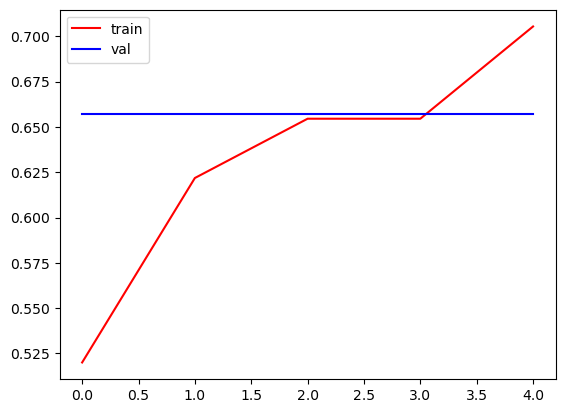

In [60]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='val')
plt.legend()
plt.show()